
**🤖 AI Lab Partner Policy: STRICTLY Opt-In Code Generation**

In this course, we treat AI tools (like ChatGPT, Gemini, Copilot) as **Lab Partners**, not solution generators. You must use the following prompt to ensure the AI acts responsibly.

**1. Copy the text inside the block below**
**2. Open your AI Assistant (Gemini, ChatGPT, etc.)**
**3. Paste the text to set the rules for the session**

> "I am a student in an Intro to Machine Learning course. Please act as my **ML Lab Partner**.
>
> **Your Rules:**
>
> 1. **Code Generation is STRICTLY Opt-In:** You **MUST NOT** generate any runnable Python code unless my message starts with one of the specific prefixes below (`code:` or `output:`).
>    * *Default Behavior:* If I ask 'How do I...?' or 'Help me with...', explain the strategy in English, provide pseudocode, or use illustrative examples. Do not generate runnable solution code.
>
> 2. **The 'code:' Trigger (Logic & Calculation):**
>    * When generating code, prioritize simplicity and human readability. Avoid complex syntax.
>    * **Constraint:** When I use this trigger, provide **only one single line of code**. Do not write full blocks.
>
> 3. **The 'output:' Trigger (Formatting & Printing):**
>    * Use this ONLY when I request code to print results, format tables, or create plots.
>    * **Exception:** For this trigger only, you **MAY** provide full multi-line code blocks to handle the verbose syntax of formatting or plotting.
>
> 4. **Wait for Me:** After providing the code, stop immediately. Wait for me to run it and ask for the next step.
>
> 5. **Explain Briefly:** Add a short comment explaining what the code does.
>
> 6. **Catch Logic Errors:** If I ask for a step that is methodologically wrong (like testing on training data), stop me and explain the error before proceeding."


# Lecture 11: Coefficient Interpretation, Correlation & Polynomial Regression

**Topics:**
1. Feature standardization and comparing coefficients
2. Correlation matrix and heatmap
3. Polynomial regression via feature engineering
4. Extrapolation warning: polynomials fail outside their training range

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

---
## 1. Feature Standardization & Coefficient Comparison

When features have different scales, raw regression coefficients are not comparable.
**Standardization** transforms each feature to have mean 0 and standard deviation 1:

$$x'_i = \frac{x_i - \bar{x}}{\sigma_x}$$

After standardization, a "1 unit change" means "1 standard deviation" for every feature, so coefficients can be compared directly.

In [55]:
# House price data
sqft = np.array([800, 1400, 1600, 2200])
bedrooms = np.array([2, 2, 4, 4])
price = np.array([175, 250, 310, 365])  # in $K

print("sqft:    ", sqft)
print("bedrooms:", bedrooms)
print("price:   ", price)

sqft:     [ 800 1400 1600 2200]
bedrooms: [2 2 4 4]
price:    [175 250 310 365]


### Key functions

```python
np.mean(array)  # Compute the mean
np.std(array)   # Compute the standard deviation (population, divides by N)
```

Example:
```python
v = np.array([10, 20, 30])
v_mean = np.mean(v)          # 20.0
v_std = np.std(v)            # 8.165...
v_standardized = (v - v_mean) / v_std  # [-1.22, 0, 1.22]
```

1. Standardize `sqft` and `bedrooms` (compute mean, std, then transform)
2. Fit a `LinearRegression` on the **raw** features
3. Fit a `LinearRegression` on the **standardized** features

Then compare: which feature has more impact on price?

In [56]:
# YOUR CODE HERE
# TODO: Compute mean and std of each feature
sqft_mean = np.mean(sqft)
sqft_std = np.std(sqft)
bed_mean = np.mean(bedrooms)
bed_std = np.std(bedrooms)
#
# TODO: Standardize each feature
sqft_s = (sqft - sqft_mean) / sqft_std
bed_s = (bedrooms - bed_mean) / bed_std
#
# TODO: Build raw and standardized feature matrices and fit models
X_raw = np.column_stack([sqft, bedrooms])
X_std = np.column_stack([sqft_s, bed_s])
#
model_raw = LinearRegression()
model_raw.fit(X_raw, price)
#
model_std = LinearRegression()
model_std.fit(X_std, price)
print(f"sqft: mean = {sqft_mean}, std = {sqft_std}")
print(f"bedrooms: mean = {bed_mean}, std = {bed_std}")
print(f"\nStandardized sqft: {sqft_s}")
print(f"Standardized bedrooms: {bed_s}")

print(f"\nRaw coefficients:")
print(f" sqft: {model_raw.coef_[0]:.4f}")
print(f" bedrooms: {model_raw.coef_[1]:.4f}")

print(f"\nStandardized coefficients:")
print(f" sqft: {model_std.coef_[0]:.4f}")
print(f" bedrooms: {model_std.coef_[1]:.4f}")

sqft: mean = 1500.0, std = 500.0
bedrooms: mean = 3.0, std = 1.0

Standardized sqft: [-1.4 -0.2  0.2  1.4]
Standardized bedrooms: [-1. -1.  1.  1.]

Raw coefficients:
 sqft: 0.1083
 bedrooms: 19.1667

Standardized coefficients:
 sqft: 54.1667
 bedrooms: 19.1667


I did not use AI to complete this problem

In [57]:
"""Check"""
assert sqft_mean == 1500, f"sqft mean should be 1500, got {sqft_mean}"
assert sqft_std == 500, f"sqft std should be 500, got {sqft_std}"
assert bed_mean == 3, f"bedrooms mean should be 3, got {bed_mean}"
assert bed_std == 1, f"bedrooms std should be 1, got {bed_std}"
assert np.allclose(sqft_s, [-1.4, -0.2, 0.2, 1.4]), "Standardized sqft values incorrect"
assert np.allclose(bed_s, [-1, -1, 1, 1]), "Standardized bedrooms values incorrect"
assert X_raw.shape == (4, 2), f"X_raw should have shape (4, 2), got {X_raw.shape}"
assert X_std.shape == (4, 2), f"X_std should have shape (4, 2), got {X_std.shape}"
print("Check passed!")

Check passed!


**Observation:** With raw coefficients, bedrooms (19.17) looks much larger than sqft (0.11). But after standardization, sqft (54.17) is actually about 3x more impactful than bedrooms (19.17). Raw coefficients are misleading when features have different scales.

---
## 2. Correlation Matrix & Heatmap

The **correlation coefficient** $\rho$ measures the linear relationship between two variables:
- $\rho = +1$: perfect positive correlation
- $\rho = -1$: perfect negative correlation
- $\rho = 0$: no linear relationship

When features are highly correlated, regression coefficients become **unstable** (small data changes can flip coefficient signs).

In [ ]:
# Student grade data
study = np.array([2, 4, 6, 8])
sleep = np.array([8, 5, 6, 3])
coffee = np.array([2, 3, 2, 4])
grade = np.array([55, 65, 73, 80])

column_names = ['study', 'sleep', 'coffee', 'grade']

### Key functions

```python
# np.corrcoef computes correlation between ROWS
# If data has shape (N, 3) with N samples and 3 variables,
# we need to transpose so each variable becomes a row:

data = np.column_stack([var1, var2, var3])  # shape (N, 3)
corr = np.corrcoef(data.T)                  # data.T has shape (3, N)
                                            # corr has shape (3, 3)
# corr[i, j] = correlation between variable i and variable j

# Heatmap
plt.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)  # Red = negative, Blue = positive
plt.colorbar()
```

1. Build a data matrix from `study`, `sleep`, `coffee`, and `grade`
2. Compute the correlation matrix using `np.corrcoef()`
3. Display it as a heatmap with `plt.imshow()`

In [58]:
# YOUR CODE HERE
# TODO: Build data matrix (N x 4)
data_matrix = np.column_stack([study, sleep, coffee, grade])
#
# TODO: Compute correlation matrix
corr_matrix = np.corrcoef(data_matrix.T)

print("Correlation matrix:")
print(np.round(corr_matrix, 2))

Correlation matrix:
[[ 1.   -0.87  0.67  1.  ]
 [-0.87  1.   -0.92 -0.87]
 [ 0.67 -0.92  1.    0.66]
 [ 1.   -0.87  0.66  1.  ]]


I did not use AI to complete this problem

In [59]:
"""Check"""
assert corr_matrix.shape == (4, 4), f"Expected shape (4, 4), got {corr_matrix.shape}"
assert np.allclose(np.diag(corr_matrix), 1.0), "Diagonal should be all 1s"
assert corr_matrix[0, 1] < -0.8, f"study-sleep correlation should be strongly negative, got {corr_matrix[0, 1]:.2f}"
assert corr_matrix[0, 3] > 0.9, f"study-grade correlation should be strongly positive, got {corr_matrix[0, 3]:.2f}"
print("Check passed!")

Check passed!


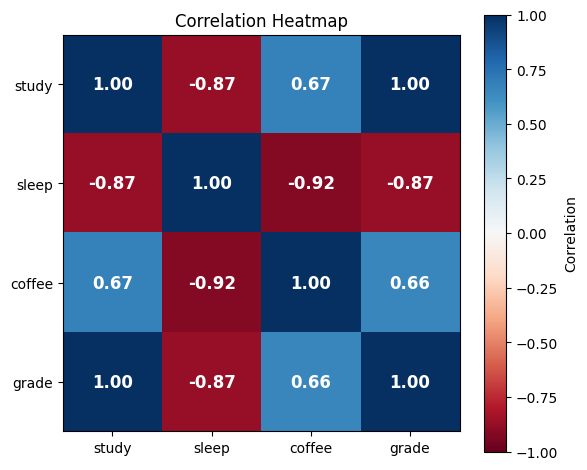

In [60]:
# Plot the heatmap
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

# Add labels
plt.xticks([0, 1, 2, 3], column_names)
plt.yticks([0, 1, 2, 3], column_names)

# Add values in each cell
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{corr_matrix[i, j]:.2f}',
                 ha='center', va='center', fontsize=12, fontweight='bold',
                 color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observation:** Study and grade are nearly perfectly correlated ($\rho = 0.997$), while sleep and grade are strongly negatively correlated ($\rho = -0.87$). The features are also highly correlated with each other (e.g., study-sleep $\rho = -0.87$, sleep-coffee $\rho = -0.92$). With such high correlations among predictors, the regression model can "trade" credit between features, making individual coefficients unreliable.

---
## 3. Polynomial Regression

Linear regression fits straight lines, but real relationships are often curved. **Polynomial regression** handles this by creating new features:

$$y = a_0 + a_1 x + a_2 x^2 + \cdots + a_M x^M$$

This is just **linear regression on the engineered features** $[1, x, x^2, \ldots, x^M]$.

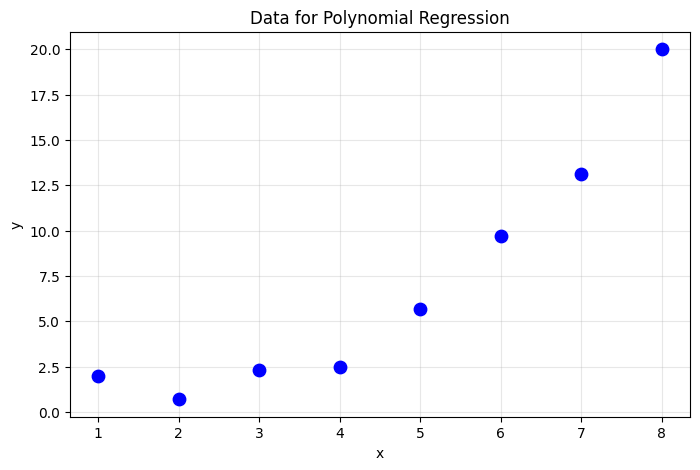

In [61]:
# Curved data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([2.0, 0.7, 2.3, 2.5, 5.7, 9.7, 13.1, 20.0])

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80, c='blue', zorder=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data for Polynomial Regression')
plt.grid(True, alpha=0.3)
plt.show()

### Key idea: Building the feature matrix

For a degree-$M$ polynomial with data points $x_1, \ldots, x_N$, the feature matrix is:

$$X = \begin{bmatrix} 1 & x_1 & x_1^2 & \cdots & x_1^M \\ 1 & x_2 & x_2^2 & \cdots & x_2^M \\ \vdots & & & & \vdots \\ 1 & x_N & x_N^2 & \cdots & x_N^M \end{bmatrix}$$

In code:
```python
# Build columns: 1, x, x^2 for degree M=2
cols = []
for p in range(M + 1):
    cols.append(x**p)
X_poly = np.column_stack(cols)

# Fit with fit_intercept=False (the ones column IS the intercept)
model = LinearRegression(fit_intercept=False)
model.fit(X_poly, y)
```

Build polynomial feature matrices for degree 1, 2, and 3, fit a `LinearRegression` model for each, and plot the results.

Degree 1 coefficients: [-4.432  2.54 ]
Degree 2 coefficients: [ 3.675 -2.324  0.54 ]
Degree 3 coefficients: [ 3.35  -1.986  0.452  0.007]


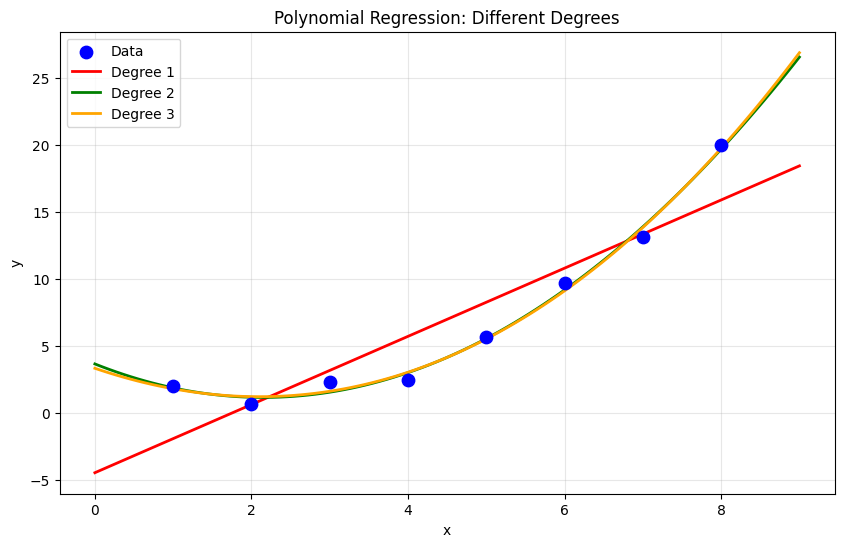

In [62]:
degrees = [1, 2, 3]
x_plot = np.linspace(0, 9, 100)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=80, c='blue', zorder=5, label='Data')

colors = ['red', 'green', 'orange']

for i in range(len(degrees)):
    M = degrees[i]
    color = colors[i]

    # YOUR CODE HERE
    # TODO: Build feature matrix with columns [1, x, x^2, ..., x^M]
    cols = []
    for p in range(M + 1):
        cols.append(x ** p)
    X_train = np.column_stack(cols)
    #
    # TODO: Fit LinearRegression (with fit_intercept=False)
    model = LinearRegression(fit_intercept=False)
    model.fit(X_train, y)
    #
    # TODO: Build feature matrix for plotting grid and predict
    cols_plot = []
    for p in range(M + 1):
        cols_plot.append(x_plot ** p)
    X_plot_feat = np.column_stack(cols_plot)
    y_pred = model.predict(X_plot_feat)

    plt.plot(x_plot, y_pred, color=color, linewidth=2, label=f'Degree {M}')
    print(f"Degree {M} coefficients: {np.round(model.coef_, 3)}")

plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression: Different Degrees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

I did not use AI to complete this problem

In [63]:
"""Check"""
# Verify degree 2 fit
X_check = np.column_stack([np.ones(len(x)), x, x**2])
model_check = LinearRegression(fit_intercept=False)
model_check.fit(X_check, y)
assert X_check.shape == (8, 3), f"Degree 2 matrix should be (8, 3), got {X_check.shape}"
assert abs(model_check.coef_[2] - 0.54) < 0.1, f"x^2 coefficient should be ~0.54, got {model_check.coef_[2]:.3f}"
print("Check passed!")

Check passed!


**Observation:** The linear fit (degree 1) misses the curvature entirely. Degree 2 captures the parabolic shape well. Degree 3 provides a bit more flexibility.

Polynomial regression is just multiple linear regression on the features $[1, x, x^2, \ldots]$. No new algorithm needed!

---
## 4. Application: Fitting a Diode Curve

The diode equation from electrical engineering describes an exponential relationship:

$$I_D = I_s \cdot (e^{V_D / V_t} - 1)$$

where $I_s = 10^{-13}$ A (saturation current) and $V_t = 0.025$ V (thermal voltage).

Let's see how well polynomials can approximate this nonlinear curve.

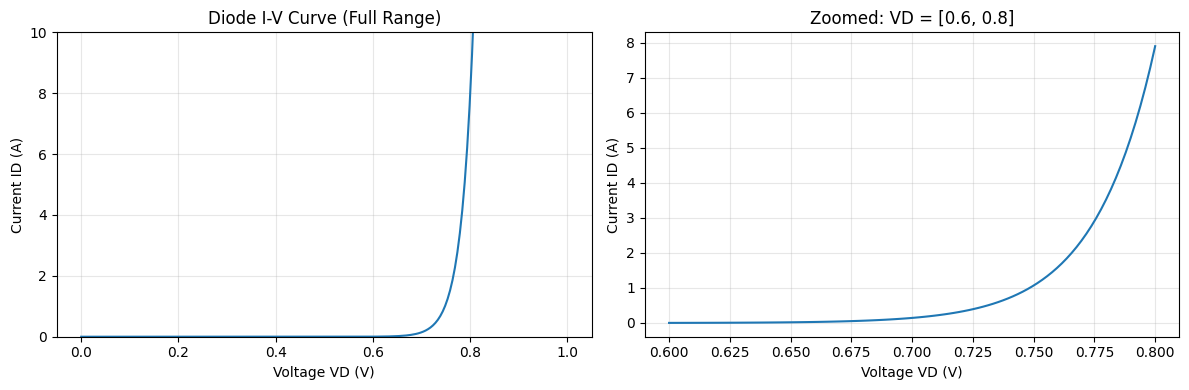

In [64]:
# --- Diode I-V Curve ---
Is = 1e-13   # Saturation current (amps)
Vt = 0.025   # Thermal voltage (volts)

# Full curve: 0 to 1 volt
x_full = np.linspace(0, 1, 200)
y_full = Is * (np.exp(x_full / Vt) - 1)

# Zoom into a region where the curve is interesting
x_zoom = np.linspace(0.6, 0.8, 100)
y_zoom = Is * (np.exp(x_zoom / Vt) - 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x_full, y_full)
ax1.set_ylim(0, 10)
ax1.set_xlabel('Voltage VD (V)')
ax1.set_ylabel('Current ID (A)')
ax1.set_title('Diode I-V Curve (Full Range)')
ax1.grid(True, alpha=0.3)

ax2.plot(x_zoom, y_zoom)
ax2.set_xlabel('Voltage VD (V)')
ax2.set_ylabel('Current ID (A)')
ax2.set_title('Zoomed: VD = [0.6, 0.8]')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Using the zoomed data (`x_zoom`, `y_zoom`), fit polynomial models of degree 1 through 4.

For each degree $M$:
1. Build the feature matrix $[1, x, x^2, \ldots, x^M]$ (same approach as Section 3)
2. Fit a `LinearRegression` model with `fit_intercept=False`
3. Compute the training SSE: $\text{SSE} = \sum (\hat{y}_i - y_i)^2$

Degree 1: SSE = 138.514534
Degree 2: SSE = 38.141898
Degree 3: SSE = 7.005294
Degree 4: SSE = 0.906550


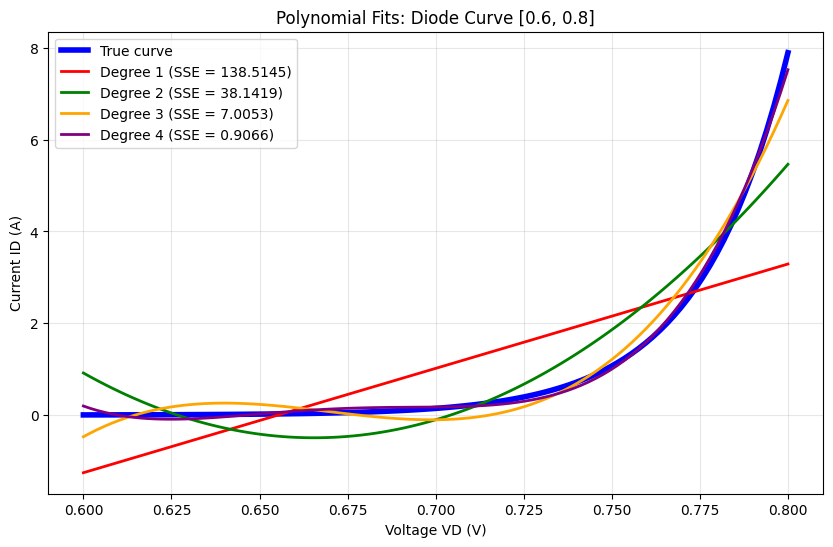

In [65]:
degrees = [1, 2, 3, 4]
colors = ['red', 'green', 'orange', 'purple']
sse_values = []

plt.figure(figsize=(10, 6))
plt.plot(x_zoom, y_zoom, 'b-', linewidth=4, label='True curve')

for i in range(len(degrees)):
    M = degrees[i]
    color = colors[i]

    # YOUR CODE HERE
    # TODO: Build feature matrix [1, x, x^2, ..., x^M]
    cols = []
    for p in range(M + 1):
        cols.append(x_zoom ** p)
    X_poly = np.column_stack(cols)
    #
    # TODO: Fit model
    model = LinearRegression(fit_intercept= False)
    model.fit(X_poly, y_zoom)
    #
    # TODO: Predict and compute SSE
    y_pred = model.predict(X_poly)
    sse = np.sum((y_zoom - y_pred)**2)

    sse_values.append(sse)
    plt.plot(x_zoom, y_pred, color=color, linewidth=2,
             label=f'Degree {M} (SSE = {sse:.4f})')
    print(f"Degree {M}: SSE = {sse:.6f}")

plt.xlabel('Voltage VD (V)')
plt.ylabel('Current ID (A)')
plt.title('Polynomial Fits: Diode Curve [0.6, 0.8]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

I did not use AI to complete this problem

In [66]:
"""Check"""
assert len(sse_values) == 4, f"Expected 4 SSE values, got {len(sse_values)}"
assert sse_values[0] > sse_values[-1], "Higher degree should have lower training SSE"
print(f"Degree 1 SSE: {sse_values[0]:.4f}")
print(f"Degree 4 SSE: {sse_values[3]:.4f}")
print("Check passed!")

Degree 1 SSE: 138.5145
Degree 4 SSE: 0.9066
Check passed!


### What happens outside the training range?

The polynomial fits look good on [0.6, 0.8]. But polynomials are just sums of powers of $x$ — they don't "know" about the exponential physics.

What happens if we use these models to predict outside the training window?

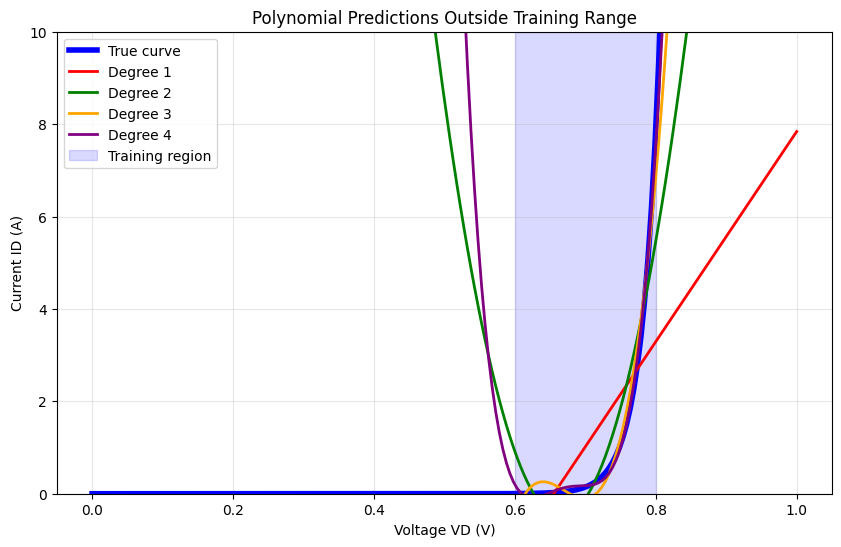

In [67]:
# --- Extrapolation: predict on [0, 1] using models trained on [0.6, 0.8] ---
plt.figure(figsize=(10, 6))
plt.plot(x_full, y_full, 'b-', linewidth=4, label='True curve')

for i in range(len(degrees)):
    M = degrees[i]
    color = colors[i]

    # Train on zoomed data
    cols = []
    for p in range(M + 1):
        cols.append(x_zoom**p)
    X_train = np.column_stack(cols)
    model = LinearRegression(fit_intercept=False)
    model.fit(X_train, y_zoom)

    # Predict on FULL range
    cols_full = []
    for p in range(M + 1):
        cols_full.append(x_full**p)
    X_full_poly = np.column_stack(cols_full)
    y_pred_full = model.predict(X_full_poly)

    plt.plot(x_full, y_pred_full, color=color, linewidth=2, label=f'Degree {M}')

plt.axvspan(0.6, 0.8, alpha=0.15, color='blue', label='Training region')
plt.xlabel('Voltage VD (V)')
plt.ylabel('Current ID (A)')
plt.title('Polynomial Predictions Outside Training Range')
plt.ylim(0, 10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** Inside the training window [0.6, 0.8], all polynomial fits look reasonable. But outside that range, they diverge wildly from the true exponential curve. Higher-degree polynomials are especially unreliable.

**Key takeaway:** Polynomials are *local* approximations. Never trust a polynomial prediction far from its training data.

**Next time (L12):** What happens when the polynomial degree gets too high *even within* the training range? We'll explore overfitting, regularization, and model selection.

---
## Summary

1. **Standardization**: Transform features to mean 0, std 1 before comparing coefficients
2. **Correlation heatmap**: Use `np.corrcoef()` and `plt.imshow()` to visualize feature relationships
3. **Polynomial regression**: Build feature matrix $[1, x, x^2, \ldots, x^M]$ and use linear regression to fit curves
4. **Extrapolation warning**: Polynomials approximate well locally but fail outside the training range